# One leg of the hedged carry book, rebuilt from the quotes

The book is a monthly sorted carry portfolio. Rank every currency by what the forward market
pays to hold it, buy the top five, sell the bottom five, equal weight. On each of those ten
legs sits an option overlay on the leg's crash side: sell the 25-delta option and buy the
10-delta one further out.

Every headline number the book reports is a weighted sum over legs. So the thing that has to
be understood before any of it means anything is one currency in one month.

This notebook takes one leg, USDJPY as of 30 June 2026, and rebuilds it twice. Once by hand
from the daily terminal prints, using nothing but numpy and scipy. Once through `fxcarry`.
Then it checks that the two agree, and that three structural identities hold on every
leg-month in the sample rather than on the one that was chosen.

The hand computation is the oracle here. The library is the thing under test.

> ### What this checks, and what it leaves alone
>
> Everything below reads `data/raw/`, which is DVC-tracked. The chain runs from the daily
> ticker prints through one leg, all 8,286 priced leg-months, and the leg's response to
> execution quality. No stored snapshot of results is read anywhere, and nothing outside
> `fxcarry` is imported.
>
> That establishes the arithmetic, and three properties it is meant to satisfy.
>
> Three things it does not establish, and which should not be claimed on the strength of it:
>
> - **The pull.** Everything takes `data/raw/` as given. Whether the ticker catalog that
>   produced it is the right one is checked nowhere.
> - **The delta convention.** Strikes come from the plain spot-delta inversion. Several pairs
>   quote a premium-adjusted delta instead, which has no closed-form inverse.
> - **That the trade is a good one.** Reproducing arithmetic says nothing about whether the
>   edge survives out of sample.

In [1]:
import pathlib

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy.stats import norm

from fxcarry import (Black76, Catalog, MarketState, ParquetSource, Smile, SpotForward,
                     Vanilla, VerticalSpread, VolSurface)

# The pulls live at the repository root, so find it rather than assume where this started.
DATA = next(p / "data" / "raw" for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "data" / "raw").is_dir())

CCY, MONTH, TAU = "JPY", "2026-06-30", 1.0 / 12.0
NEXT = "2026-07-31"

catalog = Catalog.default()
ccy = catalog[CCY]
model = Black76()

checks = []


def check(name, mine, theirs, tol=1e-12):
    "Record one hand-computed quantity against the library's answer."
    ok = abs(float(mine) - float(theirs)) <= tol
    checks.append({"quantity": name, "by hand": float(mine),
                   "library": float(theirs), "abs diff": abs(float(mine) - float(theirs)),
                   "ok": ok})
    return ok


print(f"{ccy.iso}: quoted as {ccy.pair}, a point is 1/{ccy.point_scale:,.0f} of the quote,"
      f" forwards under the {ccy.fwd_root} root")

JPY: quoted as USDJPY, a point is 1/100 of the quote, forwards under the JPY root


## From the terminal to one row

Four files carry everything this leg needs. Each is long, one row per (ticker, date, field),
which is the shape the pulls were stored in.

| file | what it holds for this leg |
| --- | --- |
| `spot_daily.parquet` | the USDJPY spot print |
| `fwd_points_1m_daily.parquet` | the 1M forward **points**, not the outright |
| `fx_vol_daily.parquet` | the at-the-money vol and the 25 and 10-delta wings |
| `tbill_daily.parquet` | the US 1M bill, the dollar leg of everything below |

A month-end resample takes the last print inside each month. Nothing here is interpolated and
nothing is filled forward.

In [2]:
def month_end(fname, tickers, field="PX_LAST"):
    "One long parquet, filtered at the file, pivoted and snapped to month ends."
    table = pq.read_table(DATA / fname,
                          filters=[("ticker", "in", list(tickers)), ("field", "==", field)])
    frame = table.to_pandas(date_as_object=False)
    frame["date"] = frame["date"].astype("datetime64[ns]")
    return (frame.pivot_table(index="date", columns="ticker", values="value")
            .resample("ME").last())


WINGS = {"atm": ("atm", "1M", None), "rr25": ("rr", "1M", 25), "bf25": ("bf", "1M", 25),
         "rr10": ("rr", "1M", 10), "bf10": ("bf", "1M", 10)}
VOL_TK = {k: ccy.vol_ticker(*args) for k, args in WINGS.items()}

spot_m = month_end("spot_daily.parquet", [ccy.spot_ticker])[ccy.spot_ticker]
points_m = month_end("fwd_points_1m_daily.parquet", [ccy.fwd_ticker("1M")])[ccy.fwd_ticker("1M")]
vol_mid = month_end("fx_vol_daily.parquet", list(VOL_TK.values())).loc[MONTH]
vol_ask = month_end("fx_vol_daily.parquet", list(VOL_TK.values()), "PX_ASK").loc[MONTH]
bill_m = month_end("tbill_daily.parquet", ["GB1M Index"])["GB1M Index"] / 100.0

print(f"{MONTH}   spot {spot_m[MONTH]:.4f}   points {points_m[MONTH]:+.2f}"
      f"   US 1M bill {100 * bill_m[MONTH]:.3f} %/yr")
print("quoted smile, in vol points:")
for k, tk in VOL_TK.items():
    print(f"   {k:5s} {vol_mid[tk]:+7.4f}   (ask {vol_ask[tk]:+7.4f})")

2026-06-30   spot 162.5500   points -40.85   US 1M bill 3.667 %/yr
quoted smile, in vol points:
   atm   +7.8400   (ask +8.0900)
   rr25  -1.1050   (ask -0.9300)
   bf25  +0.5500   (ask +0.6750)
   rr10  -2.0250   (ask -1.7250)
   bf10  +1.7150   (ask +1.9150)


## The right edge is ragged, and this leg sits on it

The pull stops in mid-July 2026. A month-end resample takes the last print inside each month,
so the row labelled 31 July carries a mid-July quote.

That matters because a leg settles against next month's spot. This leg's realized $S'$ is a
mid-July print, not a full month later. None of the arithmetic changes, but the final
leg-month in the sample settles on half a month, and any statistic computed all the way to the
end of the sample inherits that. Every leg before June 2026 is unaffected.

In [3]:
last_print = pq.read_table(DATA / "spot_daily.parquet",
                           filters=[("ticker", "==", ccy.spot_ticker)]).to_pandas()["date"].max()
print(f"last spot print in the pull   {pd.Timestamp(last_print):%Y-%m-%d}")
print(f"row labelled {NEXT}      carries {spot_m[NEXT]:.4f}")

last spot print in the pull   2026-07-15
row labelled 2026-07-31      carries 162.2000


## Forward points are not a forward

The forward file quotes points, not the outright rate, and the number of points per unit of
the quote is a per-currency convention:

$$F^{\text{nat}} \;=\; S^{\text{nat}} \;+\; \frac{\text{points}}{\text{scale}},
\qquad \text{scale}_{\text{JPY}} = 100$$

For the yen a point is 0.01 of the quote, so a print of $-40.85$ points means $-0.4085$ yen.
The scale is 10,000 for most pairs, 100 for the yen-style quotes, and 1 for a few names whose
points are quoted in whole units. Using 10,000 here would put the forward four thousandths of
a yen from spot instead of four tenths, and the implied rate differential would come out at
about one percent of its true size.

In [4]:
S_native = spot_m[MONTH]
F_native = ccy.outright(S_native, points_m[MONTH])
Sn_native = spot_m[NEXT]

print(f"spot        {S_native:9.4f}")
print(f"points      {points_m[MONTH]:+9.2f}  ->  {points_m[MONTH] / ccy.point_scale:+.4f} yen")
print(f"1M outright {F_native:9.4f}")
print(f"next spot   {Sn_native:9.4f}")

spot         162.5500
points         -40.85  ->  -0.4085 yen
1M outright  162.1415
next spot    162.2000


## Which way is up

USDJPY is quoted the way the market quotes it, yen per dollar. The library works in dollars
per foreign unit, so that a rise in the rate always means the foreign currency gained and
every pair in the panel points the same direction.

Getting this backwards flips the sign of the excess return for the four majors quoted the
other way round. The flip happens **after** the forward points are added, never before: add
points to an inverted quote and the points are in the wrong units by roughly the square of
the rate.

In [5]:
S, F, Sn = 1.0 / S_native, 1.0 / F_native, 1.0 / Sn_native

wrong = 1.0 / S_native + points_m[MONTH] / ccy.point_scale
print(f"spot        {S_native:9.4f} yen per dollar  ->  {S:.8f} dollars per yen")
print(f"1M forward  {F_native:9.4f}                 ->  {F:.8f}")
print(f"next spot   {Sn_native:9.4f}                 ->  {Sn:.8f}")
print()
print(f"the correct forward is  {F:.8f} dollars per yen")
print(f"inverting first gives  {wrong:+.8f}, which is not even a positive number:")
print("a yen point is 1/100 of a yen, and applying it to a dollars-per-yen quote")
print(f"overstates the adjustment by a factor of about {S_native ** 2:,.0f}.")

spot         162.5500 yen per dollar  ->  0.00615195 dollars per yen
1M forward   162.1415                 ->  0.00616745
next spot    162.2000                 ->  0.00616523

the correct forward is  0.00616745 dollars per yen
inverting first gives  -0.40234805, which is not even a positive number:
a yen point is 1/100 of a yen, and applying it to a dollars-per-yen quote
overstates the adjustment by a factor of about 26,423.


## The forward discount, and why it is an interest differential

Start with the arbitrage, because covered interest parity is a trade and not a theory.

Hold one dollar for a month. There are two ways to end up with dollars.

1. Stay in dollars, and it grows to $e^{r_d \tau}$.
2. Go through yen. Buy yen spot at $S$ dollars per yen, which gets you $1/S$ yen. Deposit
   them, so they grow to $e^{r_f \tau}/S$ yen. Sell that amount forward today at $F$ dollars
   per yen, so the dollars come back as $F e^{r_f \tau}/S$.

Every price in route 2 is known today, so nothing is risked. If the two differed you could
borrow the cheap route and lend the dear one for a certain profit, so they must agree:

$$e^{r_d \tau} \;=\; \frac{F}{S}\, e^{r_f \tau}
\qquad\Longleftrightarrow\qquad
\log\frac{F}{S} \;=\; (r_d - r_f)\,\tau$$

So the forward discount is an interest differential wearing different clothes. The library
reports the negative of it, annualized, and calls that the **carry**:

$$\text{carry} \;=\; -\frac{1}{\tau}\log\frac{F}{S} \;=\; r_f - r_d$$

The sign is the whole point. A currency that is dear forward is one you pay to hold, which
means it yields less than the dollar. Positive carry is the yield pickup from being long the
foreign currency, which is also what the leg earns if spot does not move. That makes it the
natural thing to sort on, and it fixes the direction:

$$q \;=\; +1 \ \text{if carry} > 0 \ \text{(buy the currency)}, \qquad -1 \ \text{otherwise}$$

In [6]:
r_d = bill_m[MONTH]
carry = -np.log(F / S) / TAU
r_f = r_d + carry
q = 1.0 if carry > 0 else -1.0
side = "put" if q > 0 else "call"          # the crash side of this leg

print(f"carry              {100 * carry:+7.3f} %/yr")
print(f"US 1M rate  r_d    {100 * r_d:7.3f} %/yr   (the bill, pulled)")
print(f"JPY 1M rate r_f    {100 * r_f:7.3f} %/yr   (from parity, never pulled)")
print(f"\nq = {q:+.0f}: the yen yields less than the dollar, so the book sells it.")
print(f"A short position loses when the yen rises, so protection is a yen {side}.")

carry               -3.019 %/yr
US 1M rate  r_d      3.667 %/yr   (the bill, pulled)
JPY 1M rate r_f      0.648 %/yr   (from parity, never pulled)

q = -1: the yen yields less than the dollar, so the book sells it.
A short position loses when the yen rises, so protection is a yen call.


## The unhedged leg, and where the $1/F$ notional comes from

Enter the 1M forward at $F$ and wait. A month later spot is $S'$ and the contract settles for
$S' - F$ dollars per yen of face. A forward costs nothing to enter, so size it so that one
dollar of capital backs the position. One dollar buys $1/F$ yen of face at the forward, so the
position pays

$$\frac{1}{F}\left(S' - F\right) \;=\; \frac{S'}{F} - 1$$

per dollar committed. Add the direction:

$$z^{\text{unhedged}} \;=\; q\left(\frac{S'}{F} - 1\right)$$

There is no compounding factor on this leg. A forward requires no cash at inception, so there
is nothing to compound. That will not be true of the option premium below, which is exactly
why the two are treated differently.

In [7]:
z_plain = q * (Sn / F - 1.0)
points_earned = -np.log(F / S)
spot_move = np.log(Sn / S)

print(f"forward points earned over the month  {100 * q * points_earned:+7.3f} %")
print(f"spot move                             {100 * q * spot_move:+7.3f} %")
print(f"                                      {'-' * 9}")
print(f"z_unhedged                            {100 * z_plain:+7.3f} %"
      f"   ({1e4 * z_plain:+.1f} bp)")

forward points earned over the month   +0.252 %
spot move                              -0.216 %
                                      ---------
z_unhedged                             +0.036 %   (+3.6 bp)


## Three quotes become a smile

Nobody quotes a volatility per strike. The market quotes three numbers per tenor and per
delta: an at-the-money level, a risk reversal (call vol minus put vol at that delta) and a
butterfly (the average of the two wings, minus at-the-money). Undoing the packaging is two
lines:

$$\sigma_{\text{call}} = \sigma_{\text{atm}} + \text{bf} + \tfrac{1}{2}\text{rr},
\qquad
\sigma_{\text{put}} = \sigma_{\text{atm}} + \text{bf} - \tfrac{1}{2}\text{rr}$$

Subtract them and the butterfly cancels, leaving the risk reversal. Average them and the risk
reversal cancels, leaving the butterfly on top of at-the-money. So the two equations invert
each other exactly, which is worth checking rather than assuming.

There is one more step, and it is the one that is easy to get wrong. Quoted risk reversals and
butterflies reference the **pair's base currency**. USDJPY is dollar-based, so the quoted call
side is a dollar call, which is a yen **put**. A yen call is therefore the quoted put side.
Swapping the two sides is exactly negating the risk reversal, because a call adds half of it
and a put subtracts half. The butterfly is symmetric and does not move.

In [8]:
def oriented(quotes):
    "The quoted smile, expressed as vols on the foreign currency, in decimals."
    flip = 1.0 if ccy.quoted_usd_per_fcu else -1.0
    return Smile(atm=quotes[VOL_TK["atm"]] / 100.0,
                 risk_reversal={d: flip * quotes[VOL_TK[f"rr{d}"]] / 100.0 for d in (25, 10)},
                 butterfly={d: quotes[VOL_TK[f"bf{d}"]] / 100.0 for d in (25, 10)})


smile, smile_ask = oriented(vol_mid), oriented(vol_ask)
sig25, sig10 = smile.vol(25, side), smile.vol(10, side)

call25, put25 = smile.vol(25, "call"), smile.vol(25, "put")
print(f"round trip at 25 delta:  call - put = {100 * (call25 - put25):+.4f}"
      f"   (quoted rr, reoriented: {-vol_mid[VOL_TK['rr25']]:+.4f})")
print(f"                    (call + put)/2 - atm = {100 * ((call25 + put25) / 2 - smile.atm):+.4f}"
      f"   (quoted bf: {vol_mid[VOL_TK['bf25']]:+.4f})")
print(f"\nyen {side} vols:   25 delta {100 * sig25:.4f}      10 delta {100 * sig10:.4f}")

round trip at 25 delta:  call - put = +1.1050   (quoted rr, reoriented: +1.1050)
                    (call + put)/2 - atm = +0.5500   (quoted bf: +0.5500)

yen call vols:   25 delta 8.9425      10 delta 10.5675


## What "25-delta" points at

A delta is not a moneyness. It is the coordinate the market quotes in, and turning it into a
strike takes the pricing model, which means the strike depends on the volatility you feed it.
That is why the smile has to be unpacked first, and why an error there moves the strike as
well as the premium.

Under the plain spot-delta convention,

$$\Delta \;=\; \omega\, e^{-r_b \tau}\, N(\omega d_1),
\qquad
d_1 = \frac{\log(F/K) + \tfrac{1}{2}\sigma^2\tau}{\sigma\sqrt{\tau}}$$

with $\omega = +1$ for a call and $-1$ for a put, and $r_b$ the rate of the **base** currency
of the quote. Working in dollars per yen makes the yen the base, so $r_b = r_f$, which came
from parity rather than from a pull.

Inverting for $K$ is closed form:

$$K \;=\; F\,\exp\!\left(-\sigma\sqrt{\tau}\,\omega\,N^{-1}\!\left(\Delta e^{r_b \tau}\right)
+ \tfrac{1}{2}\sigma^2\tau\right)$$

The honest check is not that the formula was typed correctly but that the strike maps back to
the delta it was built from.

In [9]:
omega = 1.0 if side == "call" else -1.0


def strike_from_delta(delta, sigma):
    d1 = omega * norm.ppf(delta * np.exp(r_f * TAU))
    return F * np.exp(-sigma * np.sqrt(TAU) * d1 + 0.5 * sigma**2 * TAU)


def delta_of(K, sigma):
    d1 = (np.log(F / K) + 0.5 * sigma**2 * TAU) / (sigma * np.sqrt(TAU))
    return omega * np.exp(-r_f * TAU) * norm.cdf(omega * d1)


K25, K10 = strike_from_delta(0.25, sig25), strike_from_delta(0.10, sig10)

print(f"25 delta {side}   K = {K25:.8f} $/JPY   = {1 / K25:8.4f} in the quoted direction")
print(f"10 delta {side}   K = {K10:.8f} $/JPY   = {1 / K10:8.4f}")
print(f"\nround trip:   {abs(delta_of(K25, sig25)):.10f}   {abs(delta_of(K10, sig10)):.10f}")
print(f"forward is at {F:.8f}, so both strikes sit "
      f"{'above' if K25 > F else 'below'} it, out of the money.")

25 delta call   K = 0.00627780 $/JPY   = 159.2914 in the quoted direction
10 delta call   K = 0.00641627 $/JPY   = 155.8539

round trip:   0.2500000000   0.1000000000
forward is at 0.00616745, so both strikes sit above it, out of the money.


## The two rungs, and why the loss is bounded

Premiums come from Black-76, written on the outright forward and discounted at the domestic
rate. Pricing on the forward rather than on spot keeps both interest rates out of the formula,
because the forward already carries the differential. The only rate left is the
$e^{-r_d\tau}$ out front.

The overlay does two things on the crash side, both in the same $1/F$ notional the forward
position uses: sell the 25-delta option and collect $P_{25}$, buy the 10-delta option and pay
$P_{10}$. Premium changes hands at inception, so it compounds at $r_d$ to settlement:

$$z^{\text{overlay}} \;=\; \frac{1}{F}\Big[\big(\text{payoff}_{10} - \text{payoff}_{25}\big)
+ \big(P_{25} - P_{10}\big)e^{r_d\tau}\Big]$$

Why the loss is bounded is worth doing rather than asserting. Take the call side, so both
options pay when the rate rises past their strikes, and $K_{10} > K_{25}$. Three cases:

- Below $K_{25}$: both expire worthless. The overlay is a flat lift of the net premium.
- Between the strikes: the sold option pays out and the owned one does not. The give-back
  grows linearly.
- Above $K_{10}$: both pay, and their payoffs move together one for one. The gap between them
  is frozen at $K_{10} - K_{25}$ and never widens again.

So the worst the overlay can ever cost, relative to the plain leg, is $|K_{25} - K_{10}|/F$,
a number fixed on the day the trade goes on and knowable before any of it happens.

In [10]:
disc, grow = np.exp(-r_d * TAU), np.exp(r_d * TAU)


def black(K, sigma):
    vs = sigma * np.sqrt(TAU)
    d1 = (np.log(F / K) + 0.5 * vs**2) / vs
    return omega * disc * (F * norm.cdf(omega * d1) - K * norm.cdf(omega * (d1 - vs)))


P25, P10 = black(K25, sig25), black(K10, sig10)
pay25, pay10 = max(omega * (Sn - K25), 0.0), max(omega * (Sn - K10), 0.0)

z_overlay = ((pay10 - pay25) + (P25 - P10) * grow) / F
bound = -abs(K25 - K10) / F

print(f"premium collected on the 25 delta   {1e4 * P25 * grow / F:+7.2f} bp")
print(f"premium paid on the 10 delta        {1e4 * -P10 * grow / F:+7.2f} bp")
print(f"net credit, compounded to settle    {1e4 * (P25 - P10) * grow / F:+7.2f} bp")
print(f"payoffs at settlement               {1e4 * (pay10 - pay25) / F:+7.2f} bp"
      f"   (both expired worthless)")
print(f"                                    {'-' * 9}")
print(f"z_overlay                           {1e4 * z_overlay:+7.2f} bp")
print(f"\nz_hedged = z_unhedged + z_overlay = {100 * (z_plain + z_overlay):+.3f} %")
print(f"worst the overlay could have cost   {100 * bound:.3f} %  (fixed on day one)")

premium collected on the 25 delta    +38.04 bp
premium paid on the 10 delta         -14.27 bp
net credit, compounded to settle     +23.77 bp
payoffs at settlement                 +0.00 bp   (both expired worthless)
                                    ---------
z_overlay                            +23.77 bp

z_hedged = z_unhedged + z_overlay = +0.274 %
worst the overlay could have cost   -2.245 %  (fixed on day one)


## The same leg, through the library

Everything above used numpy and scipy only. Now the same leg through `fxcarry`, and the two
are compared to twelve decimal places.

The library says the position out loud. A `MarketState` carries what is needed to value
anything: a forward, a tenor, a discount factor, the base rate the delta convention needs, the
smile, and a pricing model. A `VerticalSpread` states the rule in deltas and turns into a
position once it meets that market. The strikes only exist after the smile and the model are
supplied, which is why the rule cannot be stated in strikes.

In [11]:
market = MarketState(forward=F, tenor=TAU, discount=disc, base_rate=r_f,
                     smile=smile, model=model)

v25 = Vanilla.from_delta(25, side, market)
v10 = Vanilla.from_delta(10, side, market)
spread = VerticalSpread(sell_delta=25, buy_delta=10, kind=side).build(market)

grid = np.linspace(0.4 * F, 2.5 * F, 20001)

check("vol, 25 delta", sig25, v25.vol)
check("vol, 10 delta", sig10, v10.vol)
check("strike, 25 delta", K25, v25.strike)
check("strike, 10 delta", K10, v10.strike)
check("premium, 25 delta", P25, v25.price(market))
check("premium, 10 delta", P10, v10.price(market))
check("net premium", P25 - P10, -spread.price(market))
check("settlement payoff", pay10 - pay25, spread.payoff(Sn))
check("overlay return", z_overlay, (spread.payoff(Sn) - spread.price(market) * grow) / F)
check("loss bound", bound, spread.worst_case(grid) / F, tol=1e-6)

table = pd.DataFrame(checks).drop(columns="ok")
assert pd.DataFrame(checks)["ok"].all(), pd.DataFrame(checks).query("not ok")
print(f"{len(table)} quantities rebuilt by hand and matched to the library, "
      f"worst disagreement {table['abs diff'].max():.1e}")
print()
print(table.to_string(index=False,
                      formatters={"by hand": "{:+.12f}".format,
                                  "library": "{:+.12f}".format,
                                  "abs diff": "{:.1e}".format}))

10 quantities rebuilt by hand and matched to the library, worst disagreement 1.4e-16

         quantity         by hand         library abs diff
    vol, 25 delta +0.089425000000 +0.089425000000  0.0e+00
    vol, 10 delta +0.105675000000 +0.105675000000  0.0e+00
 strike, 25 delta +0.006277801941 +0.006277801941  0.0e+00
 strike, 10 delta +0.006416266929 +0.006416266929  0.0e+00
premium, 25 delta +0.000023388549 +0.000023388549  0.0e+00
premium, 10 delta +0.000008774545 +0.000008774545  0.0e+00
      net premium +0.000014614004 +0.000014614004  0.0e+00
settlement payoff +0.000000000000 +0.000000000000  0.0e+00
   overlay return +0.002376788591 +0.002376788591  0.0e+00
       loss bound -0.022450920805 -0.022450920805  1.4e-16


## What the overlay does to the leg, as a picture

Everything above is one point on a curve. Sweep next month's rate across a plausible range,
reprice the leg at each level, and the shape appears. The shape is the argument for the trade,
and it is the three cases from the bound derivation drawn out.

Below the 25-delta strike both options are worthless and the overlay is a parallel lift.
Between the strikes the sold option pays and the lift erodes. Beyond the 10-delta strike the
owned wing takes over, the payoffs move together, and the gap between the two lines is frozen
at the bound.

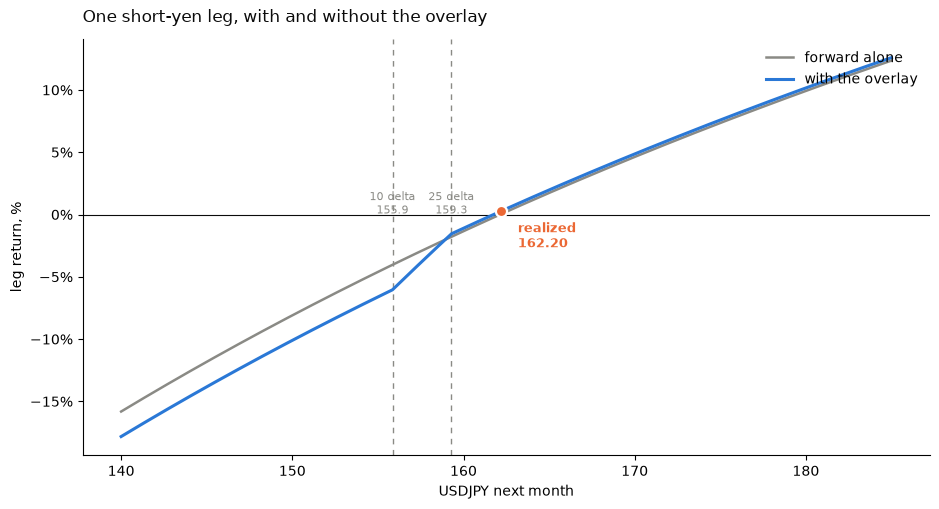

best the overlay ever does   +0.238 %   (both options expire worthless)
worst it ever does           -2.007 %   (both are deep in the money)

that worst case is the bound plus the credit already banked:
   -2.245 %  +  +0.238 %  =  -2.007 %


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#8a8a85"

grid_nat = np.linspace(140.0, 185.0, 901)
grid_usd = 1.0 / grid_nat
plain_curve = q * (grid_usd / F - 1.0)
hedged_curve = plain_curve + (spread.payoff(grid_usd) - spread.price(market) * grow) / F

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for strike, label in [(1 / K25, f"25 delta\n{1 / K25:.1f}"), (1 / K10, f"10 delta\n{1 / K10:.1f}")]:
    ax.axvline(strike, color=MUTED, lw=1, ls=(0, (4, 4)), zorder=1)
    ax.annotate(label, (strike, 0.085), ha="center", fontsize=8, color=MUTED)

ax.plot(grid_nat, 100 * plain_curve, color=MUTED, lw=1.8, label="forward alone", zorder=3)
ax.plot(grid_nat, 100 * hedged_curve, color=BLUE, lw=2.2, label="with the overlay", zorder=4)
ax.axhline(0, color=INK, lw=0.8, zorder=2)
ax.plot([Sn_native], [100 * (z_plain + z_overlay)], "o", ms=8, color=ORANGE,
        mec="white", mew=1.6, zorder=6)
ax.annotate(f"realized\n{Sn_native:.2f}", (Sn_native, 100 * (z_plain + z_overlay)),
            textcoords="offset points", xytext=(12, -26), color=ORANGE,
            fontsize=9, fontweight="bold")

ax.set_xlabel("USDJPY next month")
ax.set_ylabel("leg return, %")
ax.set_title("One short-yen leg, with and without the overlay", fontsize=12,
             color=INK, loc="left", pad=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(frameon=False, loc="upper right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# This leg is short the yen, so its crash is the yen strengthening, which is the LEFT of the
# axis. Reading the ends off the curve avoids having to remember that.
gap = 100 * (hedged_curve - plain_curve)
print(f"best the overlay ever does   {gap.max():+.3f} %   (both options expire worthless)")
print(f"worst it ever does           {gap.min():+.3f} %   (both are deep in the money)")
print()
print("that worst case is the bound plus the credit already banked:")
print(f"   {100 * bound:+.3f} %  +  {100 * (P25 - P10) * grow / F:+.3f} %"
      f"  =  {100 * (bound + (P25 - P10) * grow / F):+.3f} %")

## The same identities, on all 8,286 leg-months

One leg shows the arithmetic can be reproduced. It says nothing about whether the pipeline is
right, because a leg is one row and the panel has thousands: 33 currencies over 273 months,
including currencies that were pegged for the whole sample, currencies that floated overnight,
and one that stopped being tradable in the middle of it.

Three things ought to hold on every row, and each fails differently if the code is wrong.

1. **The decomposition.** The hedged leg is the plain leg plus the overlay, by construction.
   Any drift means something is being computed twice or on a misaligned index.
2. **The bound.** The overlay can never give back more than the strike gap. A violation means
   the payoff or the strike ordering is wrong.
3. **The strike round trip.** Every stored strike, put back through the delta formula, returns
   the delta it was built from. This is the check that catches a smile read on the wrong side,
   because the wrong volatility produces a strike that no longer maps back.

Building the panel takes seven lines. The overlay is priced twice, once with puts and once
with calls, and each leg takes the side its own direction calls for.

In [13]:
def source(*names):
    return ParquetSource(*[DATA / n for n in names])


SPOT_FILES = ("spot_daily.parquet", "spot_fwd_em_daily.parquet", "spot_fwd_broad_daily.parquet")
VOL_FILES = ("fx_vol_daily.parquet", "fx_vol_em_daily.parquet", "fx_vol_broad_daily.parquet")
FWD_FILES = ("fwd_points_1m_daily.parquet",) + SPOT_FILES[1:]

curves = SpotForward.from_quotes(
    source(*SPOT_FILES).quotes(catalog.label_map("spot"), freq="M"),
    source(*FWD_FILES).quotes(catalog.label_map("forward", "1M"), freq="M"),
    catalog, tenor=TAU)
surface = VolSurface.from_source(source(*VOL_FILES), catalog, tenors=["1M"])
panel_smile = surface.panel_smile("1M", freq="M").reindex_like(curves.forward.mid)
bill = (source("tbill_daily.parquet").series("GB1M Index", freq="M") / 100.0
        ).reindex(curves.spot.index).ffill()

raw_smile = surface.panel_smile("1M", freq="M")
print(f"spot and forwards: {len(curves.currencies)} currencies,"
      f" {curves.spot.index.min():%Y-%m} to {curves.spot.index.max():%Y-%m}")
print(f"smiles:            {raw_smile.atm.shape[1]} currencies, wings at {raw_smile.deltas}")
for d in raw_smile.deltas:
    quoted = int(raw_smile.risk_reversal[d].notna().to_numpy().sum())
    print(f"     {d:2d} delta quoted on {quoted:6,} currency-months")
print()
print("The 5-delta wing is far too thin to build a book on, so only 25 and 10 are used below.")
print("Vol coverage is also narrower than spot coverage, which is what reindex_like settles.")

spot and forwards: 35 currencies, 1983-11 to 2026-07
smiles:            33 currencies, wings at (5, 10, 25)
      5 delta quoted on  1,291 currency-months
     10 delta quoted on  8,401 currency-months
     25 delta quoted on  8,444 currency-months

The 5-delta wing is far too thin to build a book on, so only 25 and 10 are used below.
Vol coverage is also narrower than spot coverage, which is what reindex_like settles.


In [14]:
F_panel, Sn_panel = curves.forward.mid, curves.spot.mid.shift(-1)
rate = F_panel.mul(0.0).add(bill, axis=0)
panel_market = MarketState(forward=F_panel, tenor=TAU, discount=np.exp(-rate * TAU),
                           base_rate=curves.implied_foreign_rate(bill),
                           smile=panel_smile, model=model)
growth = np.exp(rate * TAU)
direction = np.sign(curves.carry)

# The crash side depends on which way the leg is held, so the rule is built on both sides and
# each leg takes its own.
built = {}
for kind in ("put", "call"):
    position = VerticalSpread(25, 10, kind).build(panel_market)
    (_, near), (_, far) = position.legs
    built[kind] = {
        "overlay": (position.payoff(Sn_panel)
                    - position.price(panel_market) * growth) / F_panel,
        "gap": (near.strike - far.strike).abs() / F_panel,
        "d25": panel_market.model.delta(kind, F_panel, near.strike, near.vol, TAU,
                                        base_rate=panel_market.base_rate).abs(),
        "d10": panel_market.model.delta(kind, F_panel, far.strike, far.vol, TAU,
                                        base_rate=panel_market.base_rate).abs()}

take = lambda key: built["put"][key].where(direction > 0, built["call"][key])
overlay, strike_gap = take("overlay"), take("gap")
plain = direction * (Sn_panel / F_panel - 1.0)
hedged = plain + overlay
live = plain.notna() & overlay.notna()
n_legs = int(live.to_numpy().sum())

give_back = (-overlay).where(live)
residual = (hedged - plain - overlay).abs()
violations = int((give_back > strike_gap.where(live) + 1e-12).to_numpy().sum())
err25 = np.nanmax((take("d25").where(live) - 0.25).abs().to_numpy())
err10 = np.nanmax((take("d10").where(live) - 0.10).abs().to_numpy())

print(f"{n_legs:,} leg-months priced, {int(live.any().sum())} currencies,"
      f" {int(live.any(axis=1).sum())} months\n")
print(f"1. decomposition      worst residual  {np.nanmax(residual.to_numpy()):.1e}")
print(f"2. loss bound         violations      {violations}"
      f"   (worst give-back {np.nanmax(give_back.to_numpy()):.2%},"
      f" largest bound {np.nanmax(strike_gap.where(live).to_numpy()):.2%})")
print(f"3. strike round trip  25 delta        {err25:.1e}")
print(f"                      10 delta        {err10:.1e}")
assert violations == 0 and max(err25, err10) < 1e-10

8,286 leg-months priced, 33 currencies, 273 months

1. decomposition      worst residual  2.8e-17
2. loss bound         violations      0   (worst give-back 7.04%, largest bound 18.01%)
3. strike round trip  25 delta        3.4e-14
                      10 delta        1.7e-14


## Where the bound actually binds

June 2026 in the yen tests nothing. Both options expired worthless and the bound was never
approached. The months that do test it have to be found rather than chosen, so the next cell
sorts the panel and reports whatever comes back.

The answer is instructive in a way that has nothing to do with the arithmetic. The largest
give-backs are dominated by the rouble, and several of them are months in which the rouble was
not tradable at all. The library prices what it is handed. Deciding that a currency stopped
being executable, and capping it there, is a research decision that belongs to whoever builds
the book, not to a pricing layer that has no way of knowing.

In [15]:
worst = give_back.stack().nlargest(8).rename("give_back").to_frame()
worst["bound"] = [strike_gap.loc[i] for i in worst.index]
worst["plain_leg"] = [plain.loc[i] for i in worst.index]
worst["slack"] = worst["bound"] - worst["give_back"]
worst.index = [f"{c} {d:%Y-%m}" for d, c in worst.index]
print(worst.to_string(formatters={c: "{:+.2%}".format for c in worst.columns}))

FREEZE = "2022-01-31"
tradable = give_back.copy()
tradable.loc[tradable.index > FREEZE, "RUB"] = np.nan
top = tradable.stack().nlargest(1)
(date, name), value = top.index[0], top.iloc[0]
print(f"\ncapping the rouble at the {FREEZE} freeze, the largest give-back becomes")
print(f"   {name} {date:%Y-%m}   {value:.2%} against a bound of {strike_gap.loc[date, name]:.2%},"
      f" on a plain leg of {plain.loc[date, name]:+.2%}")

            give_back  bound plain_leg  slack
RUB 2022-11    +7.04% +7.78%   -17.39% +0.74%
RUB 2008-12    +6.73% +8.41%   -13.17% +1.69%
HUF 2008-12    +6.49% +7.52%   -17.67% +1.03%
RUB 2014-11    +6.18% +7.99%   -13.83% +1.82%
RUB 2022-01    +5.29% +5.91%   -26.05% +0.62%
PLN 2008-12    +5.16% +8.64%   -14.41% +3.49%
BRL 2008-09    +4.99% +6.17%   -11.13% +1.18%
CZK 2008-12    +4.89% +6.38%   -11.85% +1.49%



capping the rouble at the 2022-01-31 freeze, the largest give-back becomes
   RUB 2008-12   6.73% against a bound of 8.41%, on a plain leg of -13.17%


## The overlay is an execution trade

Every premium above was priced at mid, and nobody trades at mid. The overlay sells one option
and buys another, so it crosses two spreads, and the pickup is precisely the quantity a spread
eats into.

The vol quotes carry an ask as well as a mid, so the honest question is not "what do costs do"
but "how much of the quoted spread can be paid before the edge is gone". Sell the 25-delta at
the mid vol minus a fraction $\phi$ of its half-spread, buy the 10-delta at the mid plus the
same fraction, and trace the pickup as $\phi$ runs from 0 to 1.

The strikes stay on the mid smile throughout, because that is what a desk quotes the structure
against. Only the prices move.

In [16]:
half25 = smile_ask.vol(25, side) - smile.vol(25, side)
half10 = smile_ask.vol(10, side) - smile.vol(10, side)


def pickup_at(phi):
    "Net credit when a fraction phi of each rung's quoted half-spread is paid."
    sold = Vanilla(side, K25, sig25 - phi * half25)      # sold lower, so worse
    owned = Vanilla(side, K10, sig10 + phi * half10)     # bought higher, so worse
    return float((sold.price(market) - owned.price(market)) / F)


fills = np.linspace(0.0, 1.0, 11)
curve = np.array([pickup_at(x) for x in fills])
straight = curve[0] + fills * (curve[-1] - curve[0])

print("phi   " + "".join(f"{x:7.0%}" for x in fills))
print("bp    " + "".join(f"{1e4 * v:7.2f}" for v in curve))
print(f"\nhalf-spread on the sold rung {100 * half25:.3f} vol points,"
      f" on the owned rung {100 * half10:.3f}")
print(f"mid pickup {1e4 * curve[0]:.2f} bp, full-spread pickup {1e4 * curve[-1]:.2f} bp,"
      f" a loss of {1 - curve[-1] / curve[0]:.1%}")
print(f"departure from a straight line, at most {1e4 * np.abs(curve - straight).max():.3f} bp")

phi        0%    10%    20%    30%    40%    50%    60%    70%    80%    90%   100%
bp      23.70  23.28  22.87  22.45  22.03  21.62  21.20  20.79  20.37  19.95  19.53

half-spread on the sold rung 0.288 vol points, on the owned rung 0.300
mid pickup 23.70 bp, full-spread pickup 19.53 bp, a loss of 17.6%
departure from a straight line, at most 0.004 bp


## What this establishes, and what it does not

Rebuilt from the daily terminal prints and matched to the library to twelve decimal places:
the month-end resample and the forward-points conversion, the quote inversion, the carry and
the parity-implied yen rate, the direction rule, the unhedged leg return, both crash-side vols
out of the quoted smile, both strikes from their deltas and both deltas back from their
strikes, both premiums, the net credit, the settlement payoff, the overlay return and the
loss bound.

Across all 8,286 priced leg-months: the decomposition holds to machine precision, the bound is
never violated, and every strike round-trips to the delta it was built from within $10^{-13}$.

Not established here, and it should not be claimed:

- **The pull.** Everything takes `data/raw/` as given.
- **The delta convention.** Strikes use the plain spot-delta inversion throughout. Several
  pairs quote a premium-adjusted delta, which has no closed-form inverse.
- **The smile between quotes.** Only the deltas the market quotes are used. Nothing here
  interpolates, and any structure at a delta that was not quoted would need a smile model.
- **That the edge is real.** One tight yen smile in a quiet month proves nothing about a book
  that has to hold ten legs a month for twenty years, several of them in currencies whose
  options barely trade. The execution sweep above is one leg. The book-level version of that
  question, and what the rung choice does to the shape of the return distribution, is the next
  notebook.